In [1]:
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
import random as rd
from scipy.optimize import minimize
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import csv
from scipy.signal import convolve2d, convolve
from sklearn.ensemble import IsolationForest

C:\Users\dylan\AppData\Local\Temp\ipykernel_20384\3401371208.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
n = 10
def create_data_array(directory) :
    datalist = []
    for i in range(n):
        filename = os.listdir(directory)[i]
        if filename.endswith(".npy"):
            data_day = np.load(directory + '/' + filename)
        datalist.append(data_day)
    data_raw = np.concatenate(datalist,axis=0)
    return data_raw

data_raw = create_data_array(r'datatest')

day_one = data_raw[:288,:,:]

In [2]:
kernel_3D = np.array([[[-1,-1,-1],[-1,-1,-1],[-1,-1,-1]],[[-1,-1,-1],[-1,26,-1],[-1,-1,-1]],[[-1,-1,-1],[-1,-1,-1],[-1,-1,-1]]])
kernel_2D = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
Score_day_one = convolve(day_one,kernel_3D)

data_raw_30_min = np.array([np.sum(data_raw[6*i:6*i+6,:,:],axis=0) for i in range(len(data_raw)//6) ])
Score_30_min = np.array([convolve2d(data_raw_30_min[i],kernel_2D,mode='same') for i in range(np.shape(data_raw_30_min)[0])])
print(data_raw_30_min)

NameError: name 'day_one' is not defined

[0 0 0 ... 0 0 0]
61.714285714285715 27.535505835786875
36.001200000057
144.32080322164634


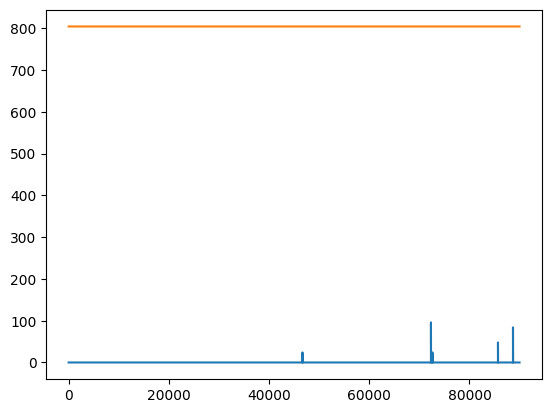

In [25]:
A_test = np.reshape(data_raw[2220,:,:],-1)
A_non_zero = A_test[A_test>0]
print(A_test)
mu = np.mean(A_non_zero)
sigma =np.std(A_non_zero)
print(mu,sigma)
Q = np.percentile(A_test,99.995)
print(Q)
Q25 = np.percentile(A_non_zero,25)
Q75 = np.percentile(A_non_zero,75)
IQR = Q75-Q25
frontier = mu + 3*sigma
frontier_2 = Q75 + 15*IQR
print(frontier)
plt.plot(A_test)
plt.plot(range(len(A_test)),[frontier_2 for i in range(len(A_test))])
plt.show()


In [6]:
random_list = [rd.randint(0,len(day_one)-1) for i in range(100)]

In [16]:
kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
kernel_2 = np.array([[-1,-1,-1,-1,-1],[-1,-2,-2,-2,-1],[-1,-2,32,-2,-1],[-1,-2,-2,-2,-1],[-1,-1,-1,-1,-1]])
S_1=[convolve2d(data_raw[t],kernel,mode='same') for t in random_list]
S_2=[convolve2d(data_raw[t],kernel_2,mode='same') for t in random_list]

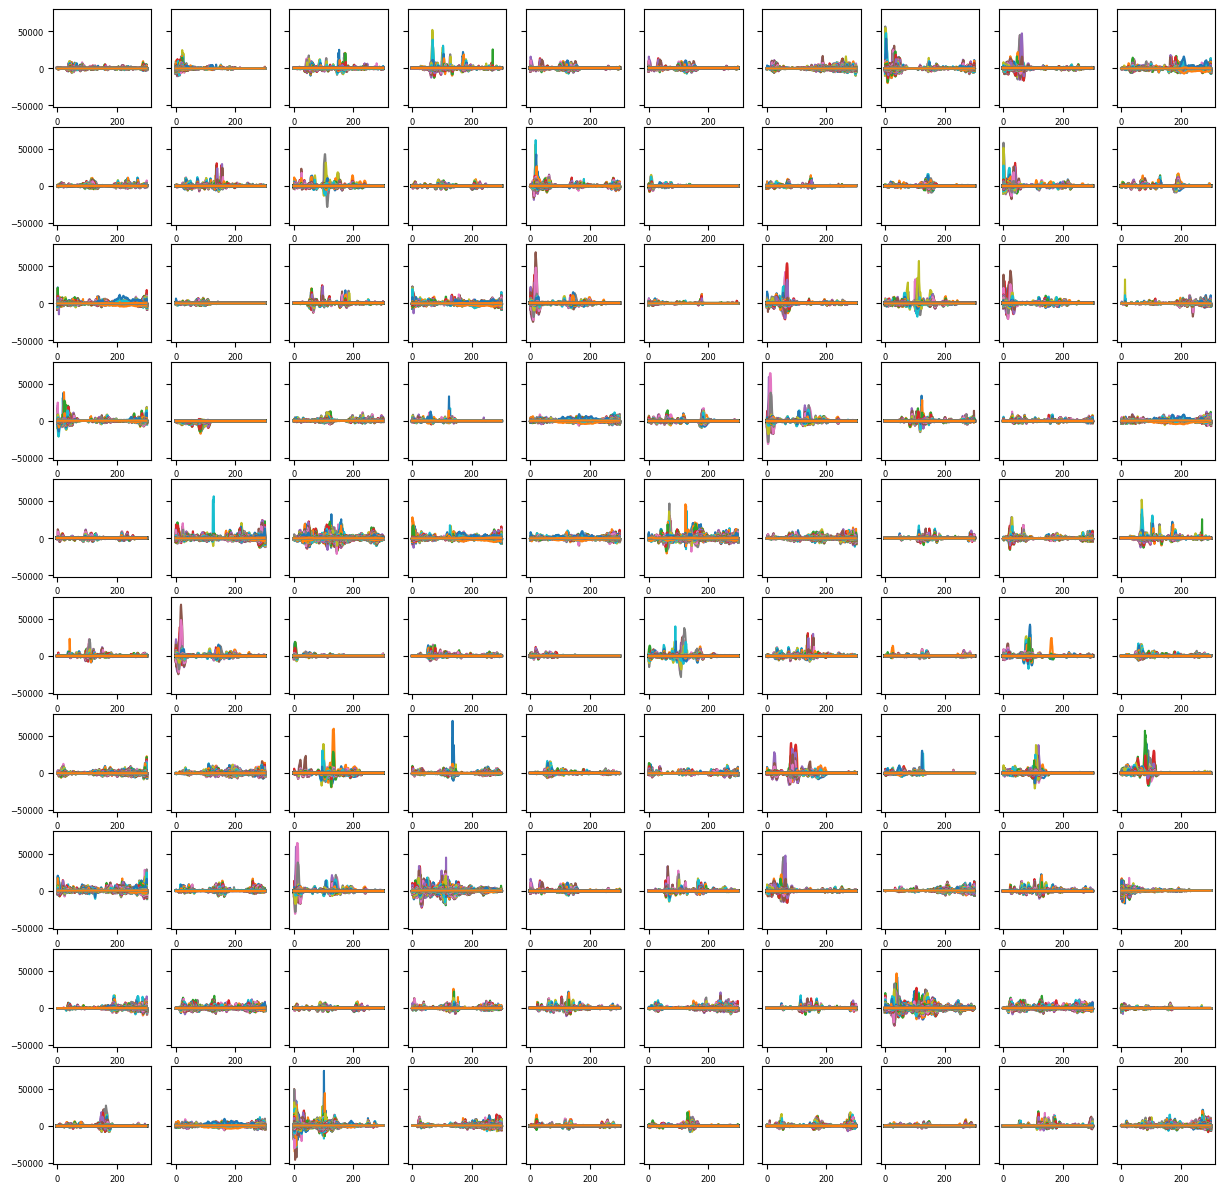

In [9]:
fig, ax = plt.subplots(10, 10, sharey='all', figsize=(15, 15))
for i, idx in enumerate(random_list):
    A_test = np.reshape(Score_day_one[idx,:,:], -1)
    ax[i // 10, i % 10].plot(Score_day_one[idx,:,:])
    ax[i // 10, i % 10].plot(day_one[idx,:,:])
    ax[i // 10, i % 10].tick_params(axis='both', which='both', labelsize=6)
plt.show()




In [23]:
rdlist2 = [rd.randint(0,len(data_raw_30_min)-1) for i in range(100)]

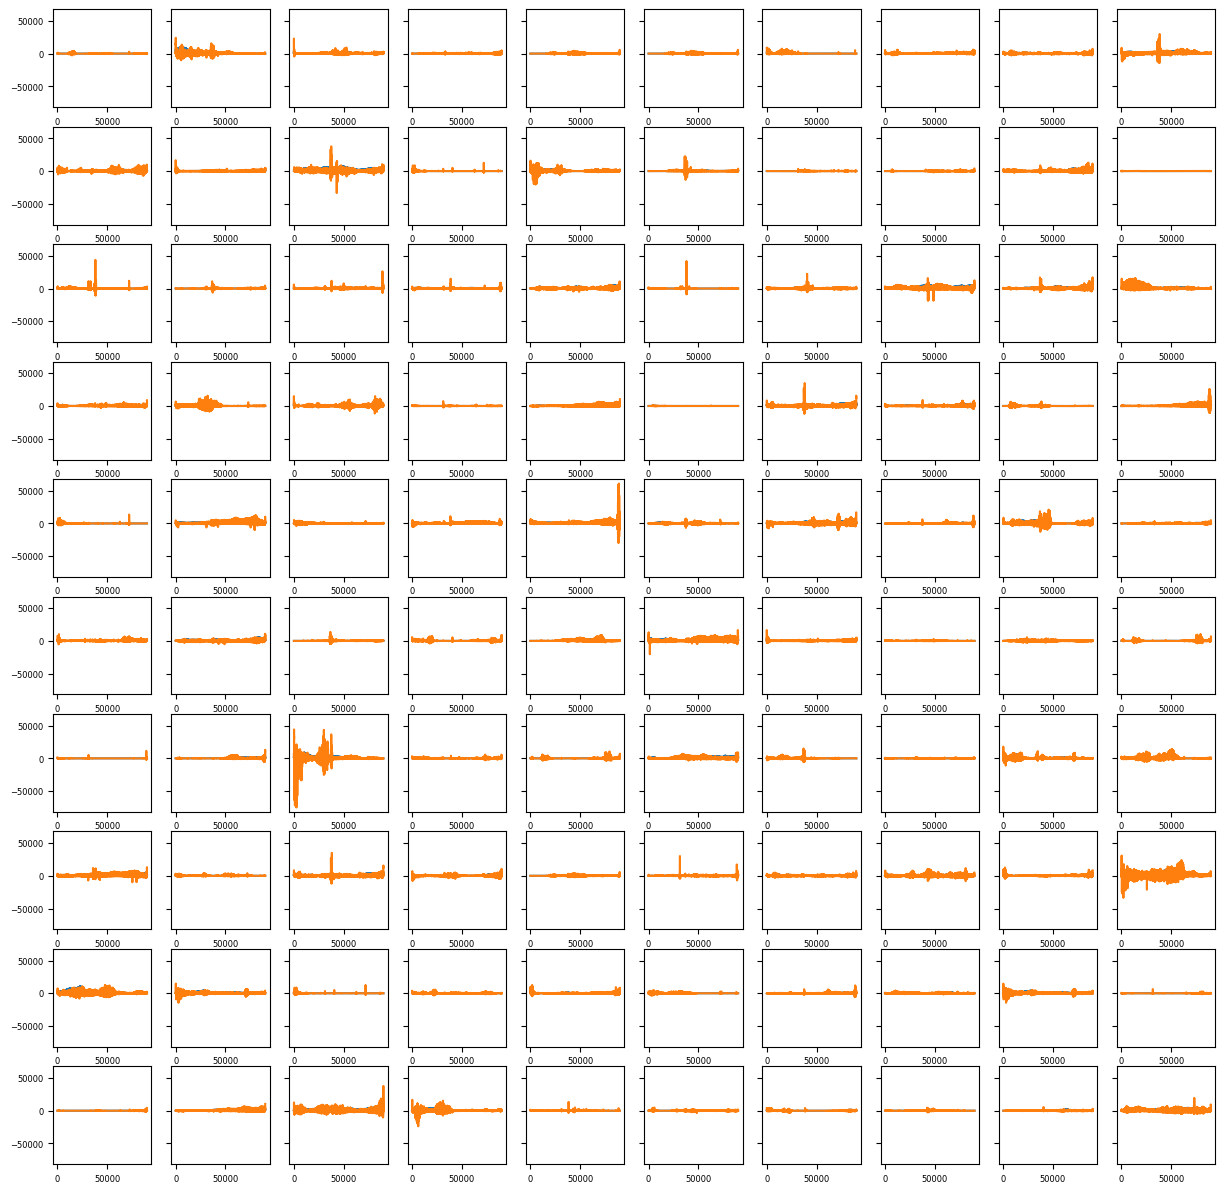

In [22]:


fig, ax = plt.subplots(10, 10, sharey='all', figsize=(15, 15))
for i, idx in enumerate(random_list):
    B_test = np.reshape(data_raw_30_min[idx], -1)
    S_test = np.reshape(Score_30_min[idx], -1)
    ax[i // 10, i % 10].plot(B_test)
    ax[i // 10, i % 10].plot(S_test)
    ax[i // 10, i % 10].tick_params(axis='both', which='both', labelsize=6)
plt.show()



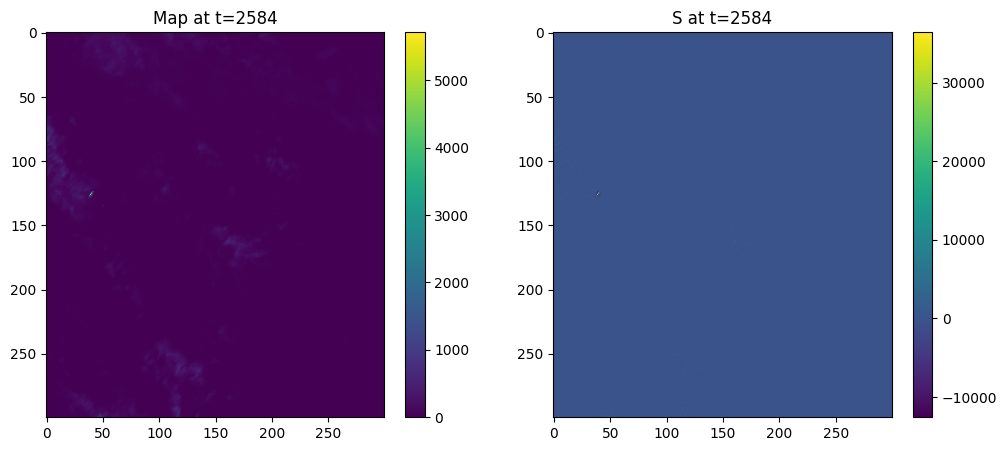

In [15]:
S = convolve2d(data_raw[2584,:,:],kernel,mode='same')
fig, axes = plt.subplots(1, 2,figsize=(12,5))
cax = axes[0].imshow(data_raw[2584,:,:], aspect='auto', cmap='viridis')
axes[0].set_title(f'Map at t=2584')
fig.colorbar(cax, ax=axes[0])
cax = axes[1].imshow(S, aspect='auto', cmap='viridis')
axes[1].set_title(f'S at t=2584')
fig.colorbar(cax, ax=axes[1])
plt.show()



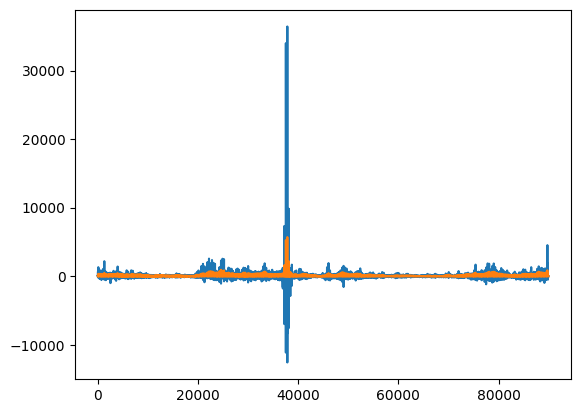

In [14]:
S_bar = np.reshape(S,-1)
A_bar = np.reshape(data_raw[2584,:,:],-1)
plt.plot(S_bar)
plt.plot(A_bar)
plt.show()

KeyboardInterrupt: 

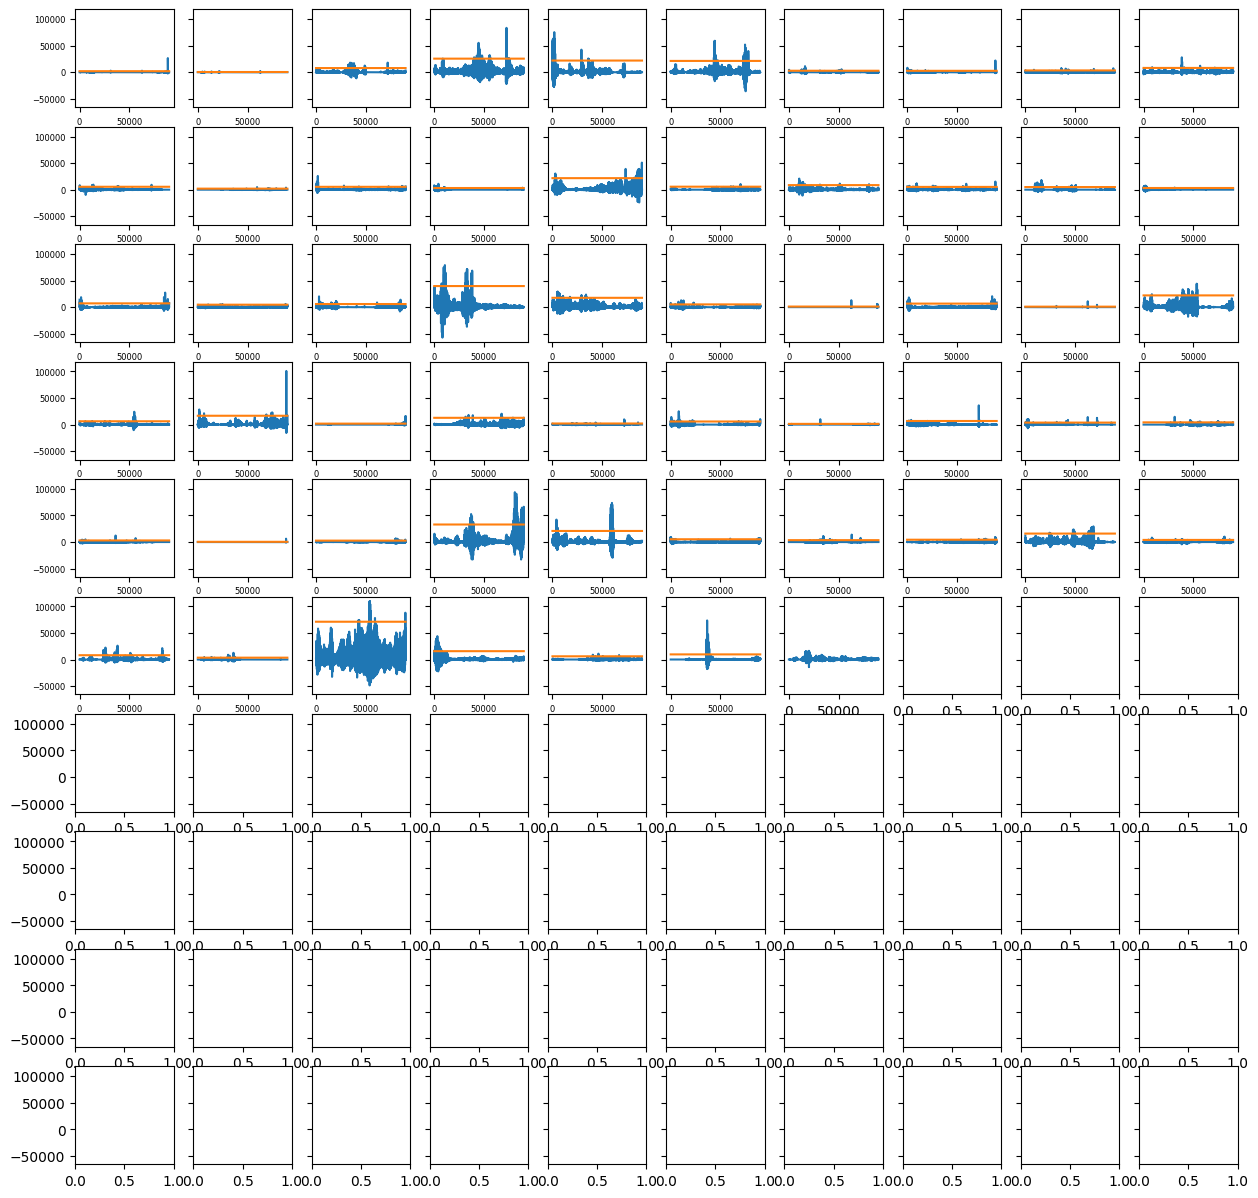

In [21]:
fig, ax = plt.subplots(10, 10, sharey='all', figsize=(15, 15))
for i, idx in enumerate(random_list):
    A_test = np.reshape(data_raw[idx,:,:], -1)
    B_test = np.reshape(S_1[i], -1)
    C_test = np.reshape(S_2[i], -1)
    D_test = A_test+B_test+C_test
    ax[i // 10, i % 10].plot(D_test)
    ax[i // 10, i % 10].plot([np.mean(D_test)+20*np.std(D_test) for i in range(90000)])
    ax[i // 10, i % 10].tick_params(axis='both', which='both', labelsize=6)
plt.show()

ValueError: Expected 2D array, got 1D array instead:
array=[252. 288. 179. ...   0.   0.   0.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

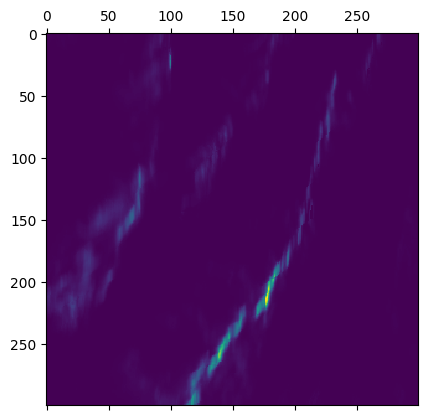

In [19]:
plt.matshow(data_raw[629])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


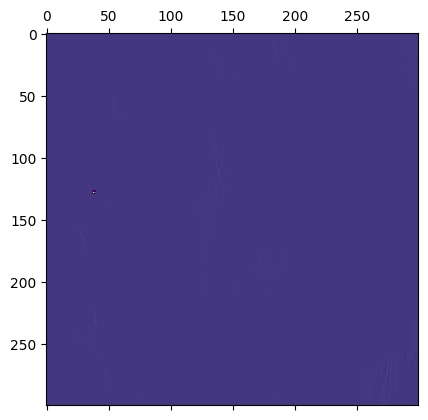

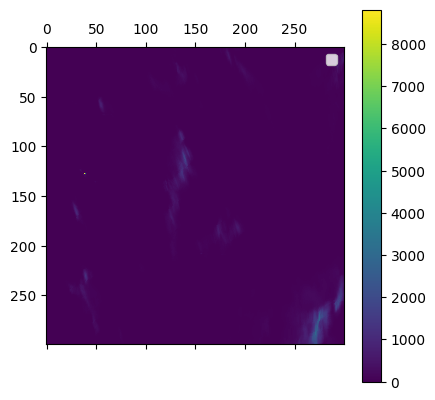

In [5]:
def find_neighbors(A, i0, j0, rho):
    rows, cols = A.shape
    neighbors = []
    
    for i in range(max(0, i0 - int(np.floor(rho))), min(rows, i0 + int(np.floor(rho)) + 1)):
        for j in range(max(0, j0 - int(np.floor(rho))), min(cols, j0 + int(np.floor(rho)) + 1)):
            if (i != i0 or j != j0) and ((i - i0)**2 + (j - j0)**2 < rho**2):
                neighbors.append((i, j))
                
    return np.array(neighbors)


def score(A,rho):
    N = np.shape(A)
    Score_matrix = np.zeros(N)
    for i in range(N[0]):
        for j in range(N[1]):
            L = find_neighbors(A,i,j,rho)
            L_value = [A[e[0],e[1]] for e in L]
            Score_matrix[i,j] = (len(L)+1)*A[i,j]- np.sum(L_value)
    return Score_matrix


Kernel_1 = np.array([[-1,-1,-1,-1,-1],[-1,-1,-1,-1,-1],[-1,-1,24,-1,-1],[-1,-1,-1,-1,-1],[-1,-1,-1,-1,-1]])
Kernel_2 = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
S = convolve2d(data_raw[680,:,:],Kernel_2,mode='same')
plt.matshow(S)
plt.matshow(data_raw[680,:,:])
plt.colorbar()
plt.legend()

251.9223111111111 1197.1058561974435
5996.087000004132


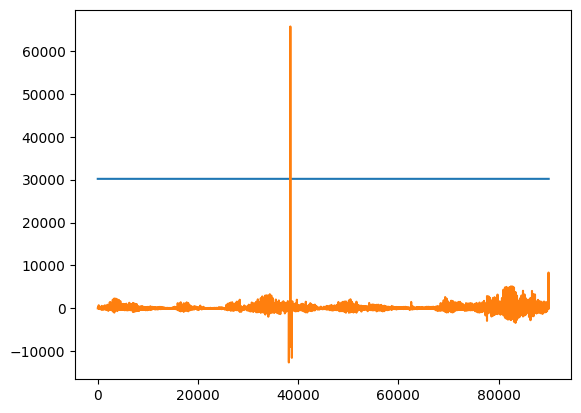

In [6]:
B_test = np.reshape(S,-1)
B_2_test = np.reshape(data_raw[680,:,:],-1)
mu = 8*np.mean(B_2_test)
sigma =8*np.std(B_2_test)
print(mu,sigma)
Q = np.percentile(B_test,99.995)
print(Q)
Q25 = np.percentile(B_test,25)
Q75 = np.percentile(B_test,75)
IQR = Q75-Q25
frontier = mu + 25*sigma
frontier_2 = Q75 + 15*IQR

plt.plot(range(len(B_test)),[frontier for i in range(len(B_test))])

plt.plot(B_test)
plt.show()

[192, 208, 199, 233, 211, 89, 91, 229, 176, 25, 281, 63, 71, 37, 12, 156, 92, 35, 85, 112, 108, 47, 171, 167, 56, 254, 244, 249, 140, 192, 209, 238, 97, 116, 230, 79, 83, 173, 161, 156, 15, 112, 37, 168, 264, 61, 282, 263, 76, 103, 74, 156, 33, 98, 142, 234, 195, 22, 212, 267, 57, 248, 190, 45, 173, 287, 124, 257, 228, 133, 149, 264, 74, 120, 7, 88, 70, 8, 188, 268, 253, 197, 210, 151, 276, 239, 4, 227, 163, 199, 121, 262, 149, 11, 66, 116, 276, 100, 236, 248]
192


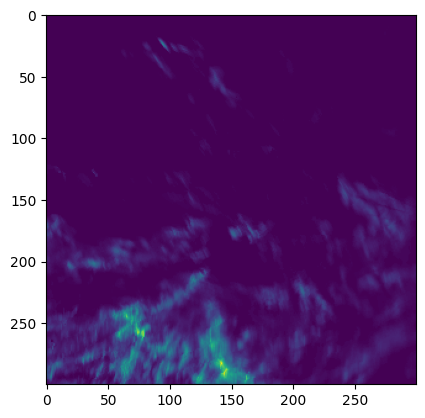

208


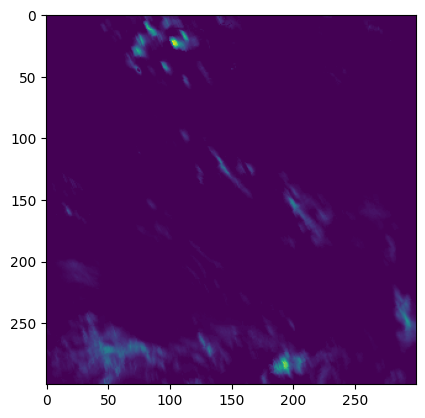

199


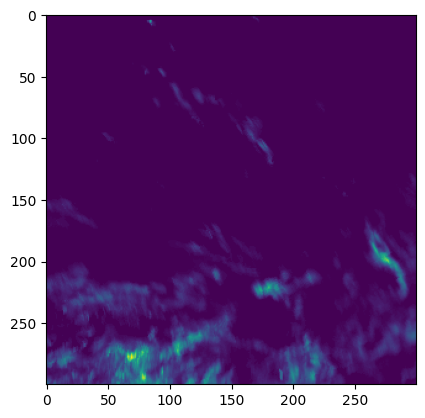

233


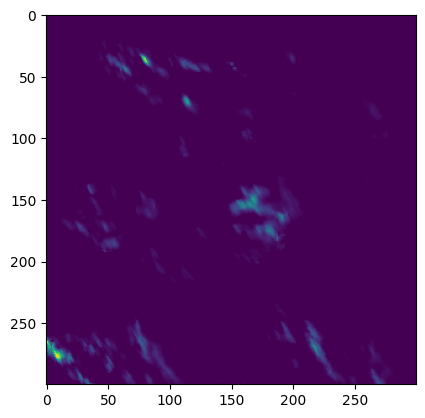

211


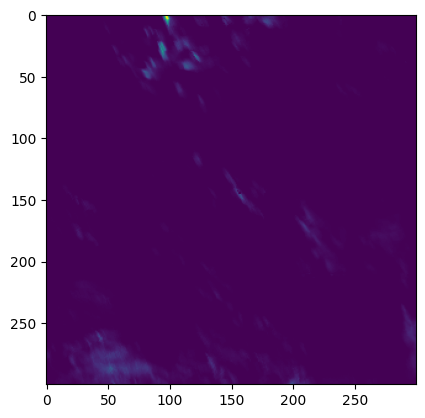

89


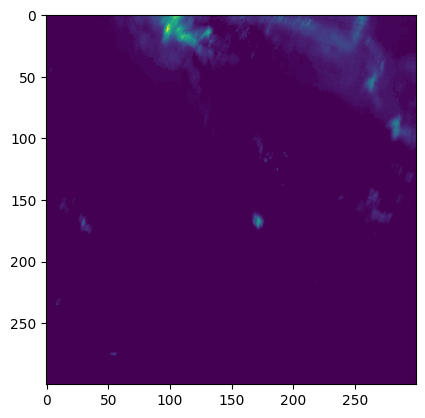

91


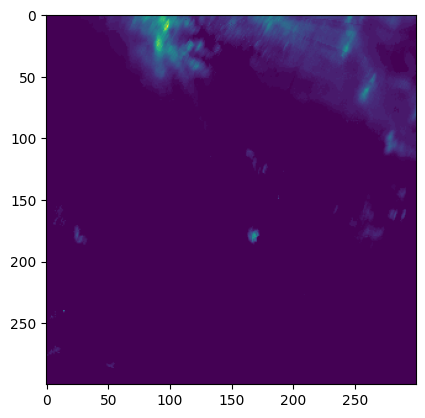

229


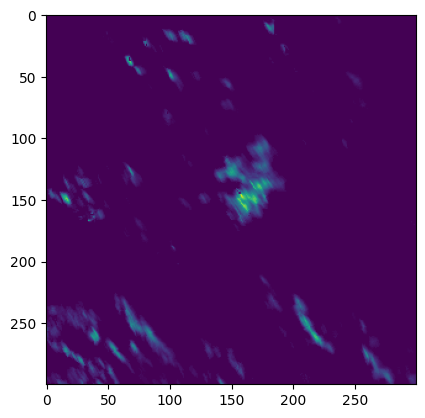

176


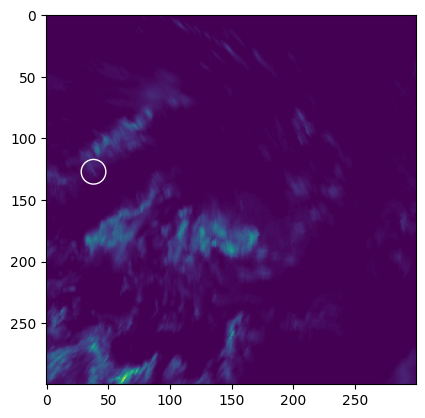

25


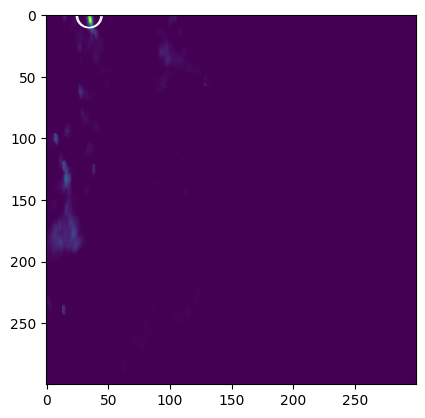

281


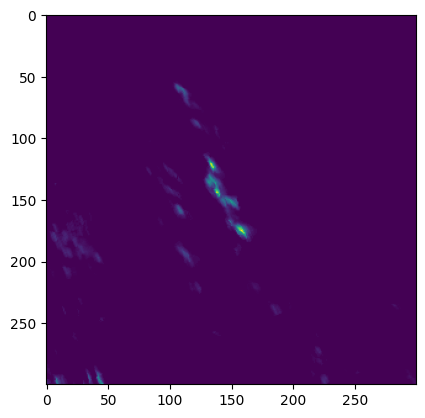

63


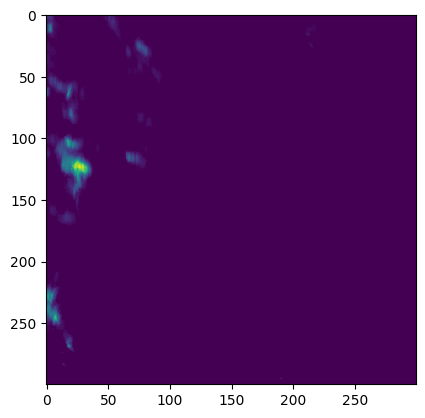

71


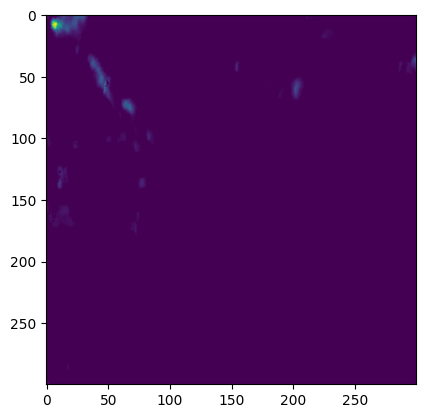

37


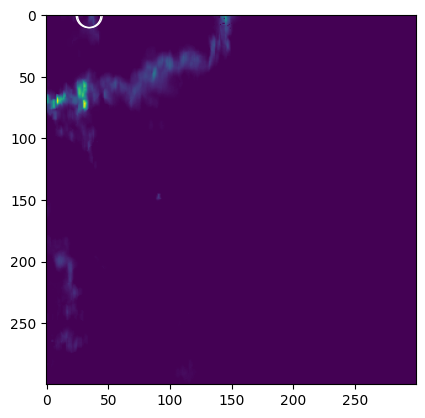

12


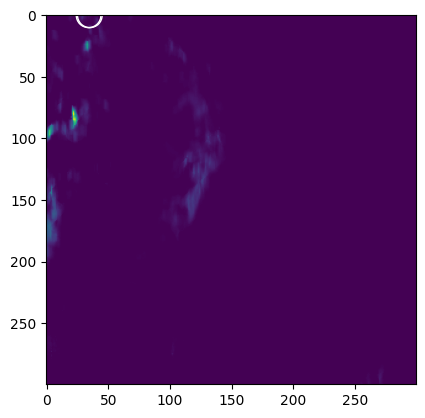

156


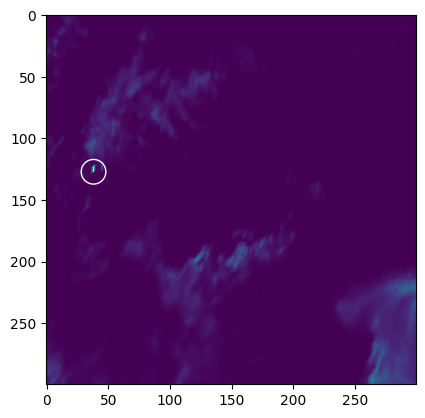

92


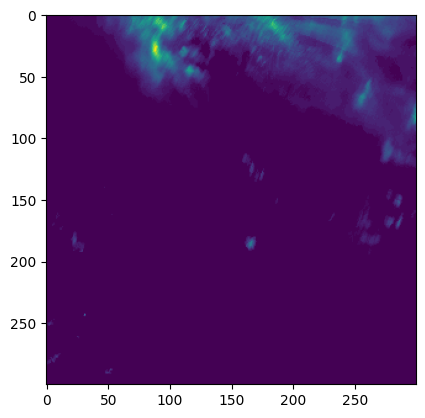

35


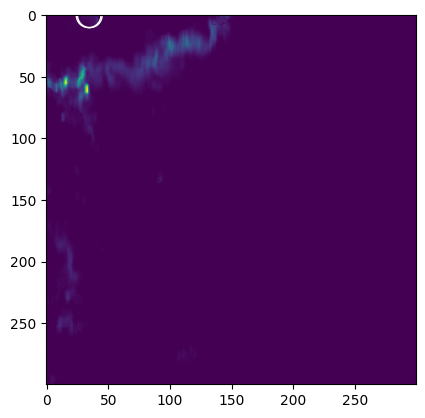

85


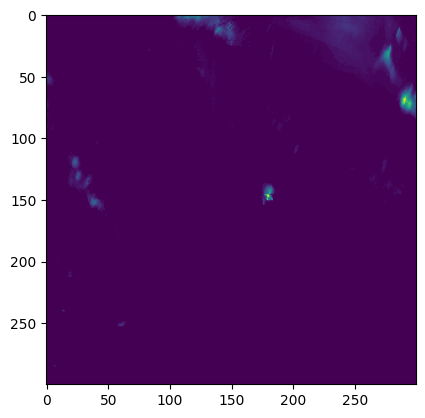

112


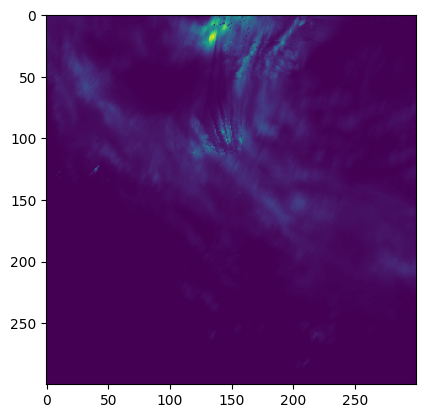

108


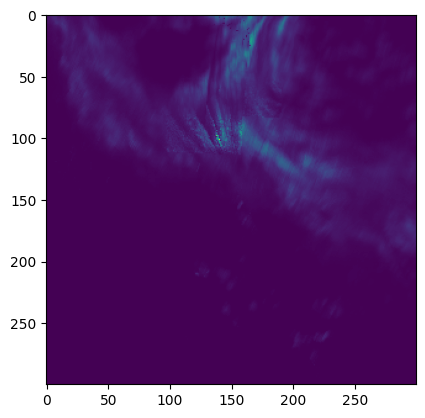

47


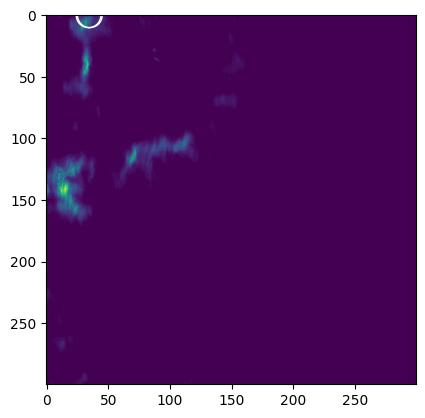

171


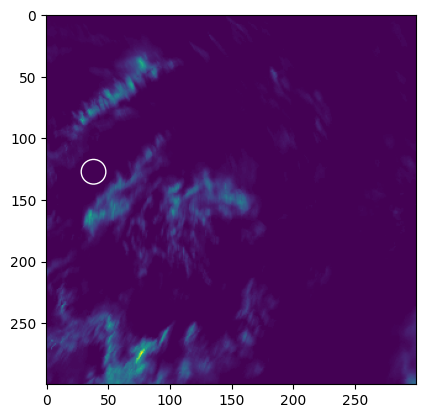

167


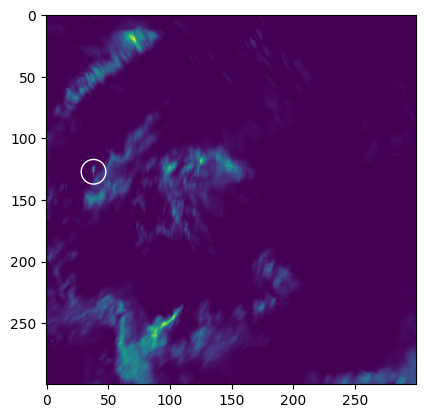

56


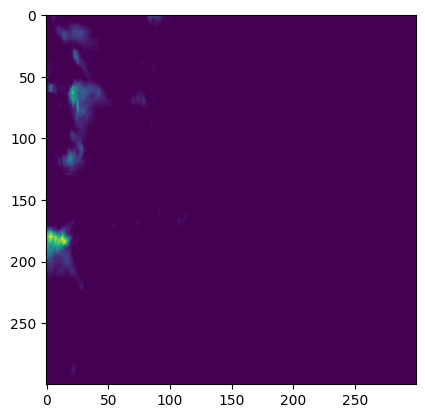

254


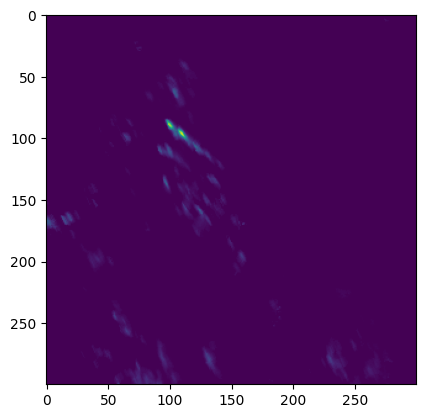

244


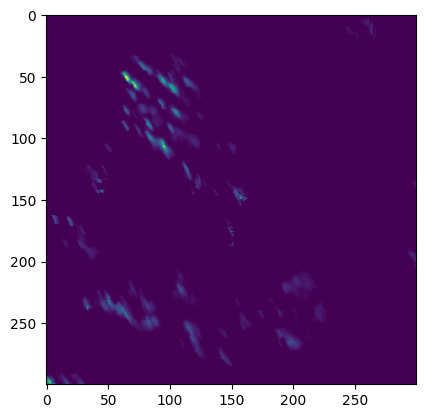

249


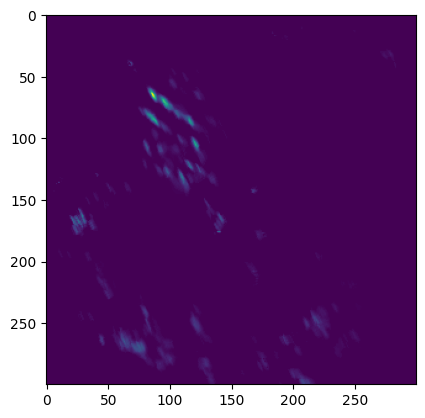

140


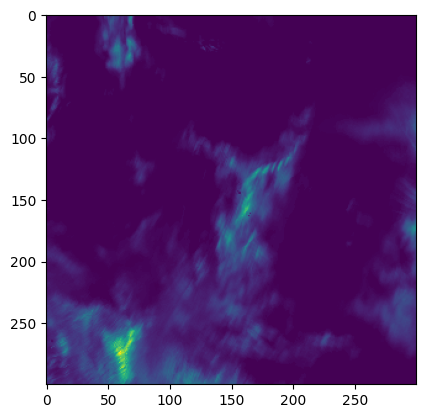

192


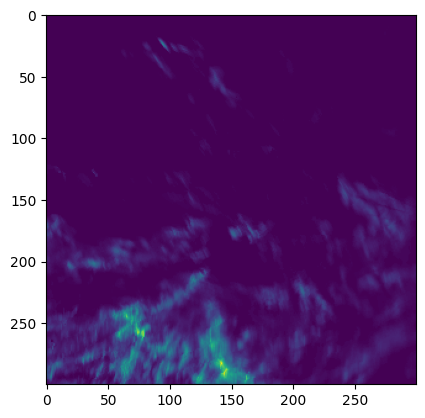

209


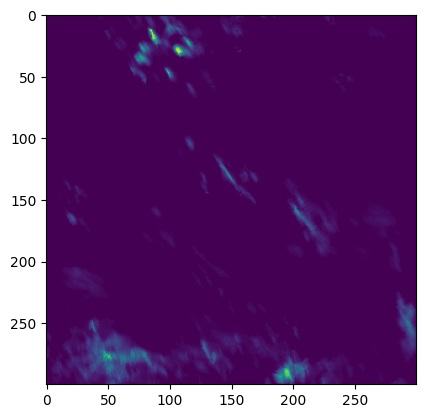

238


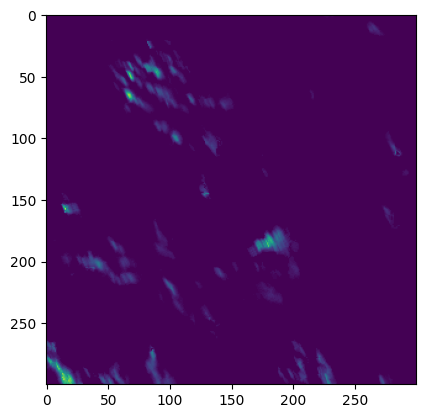

97


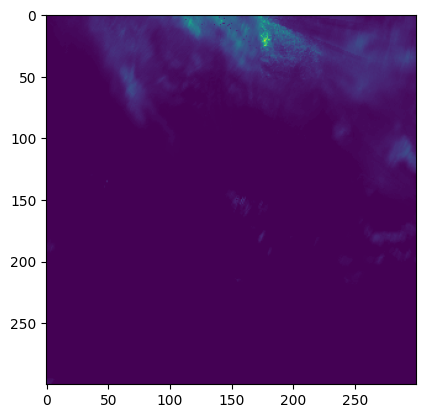

116


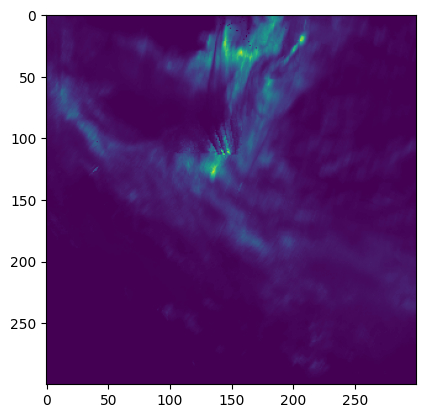

230


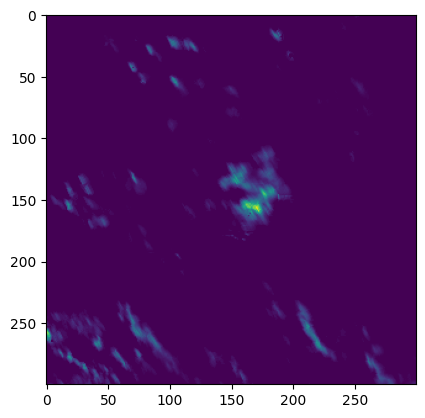

79


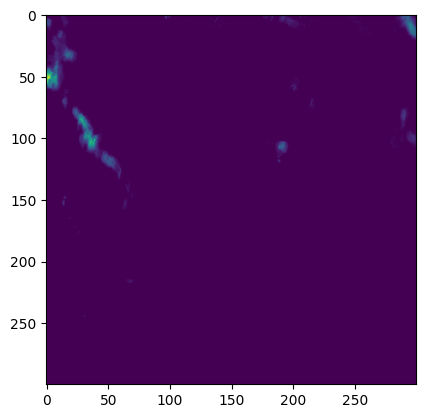

83


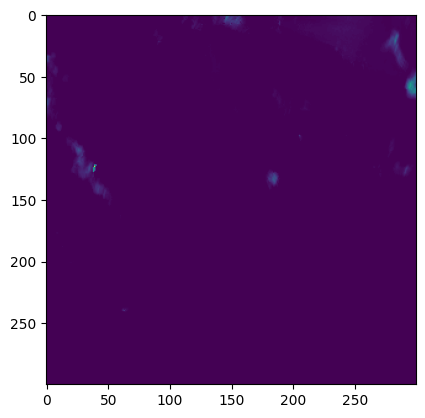

173


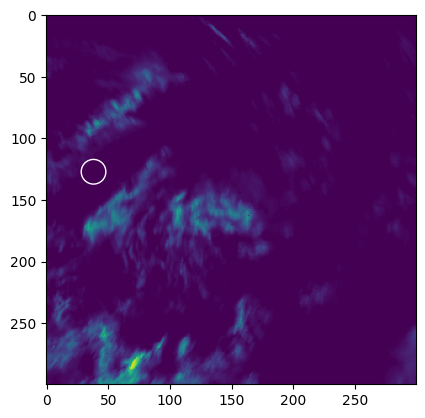

161


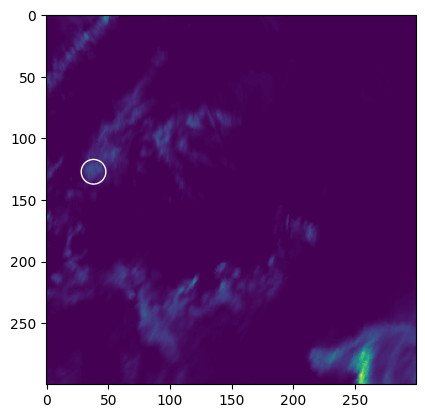

156


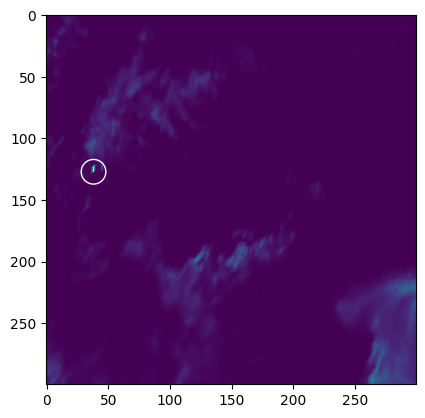

15


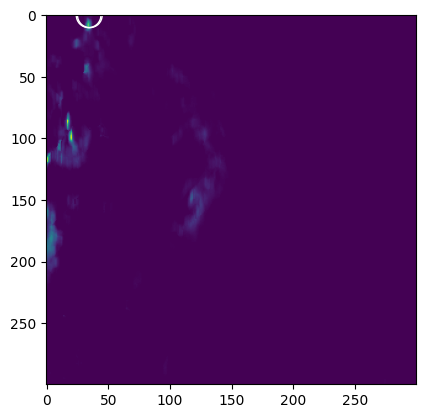

112


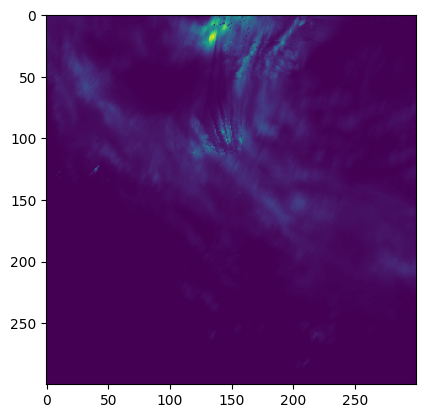

37


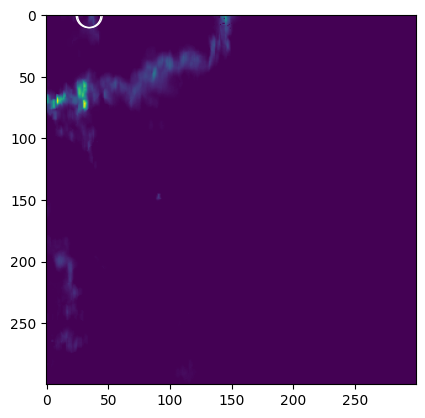

168


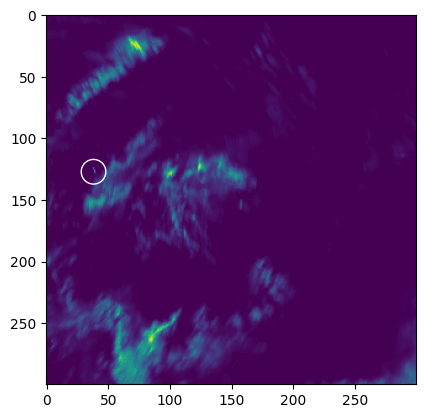

264


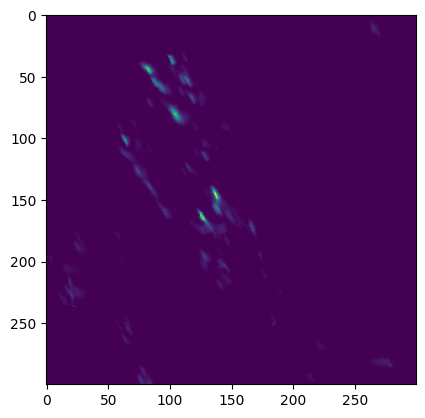

61


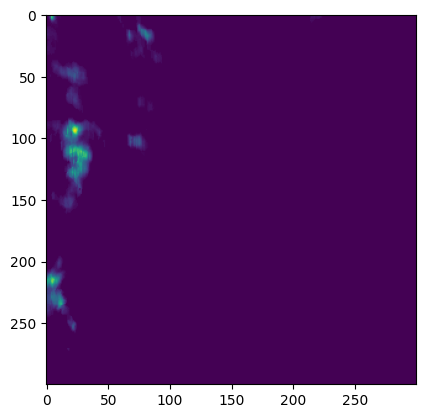

282


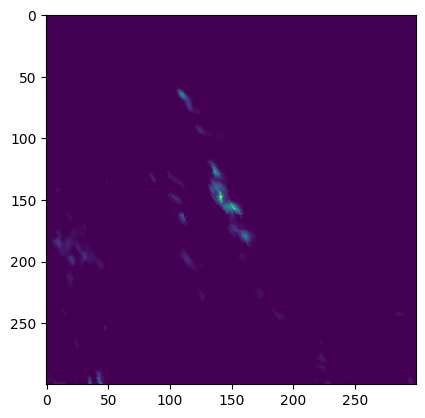

263


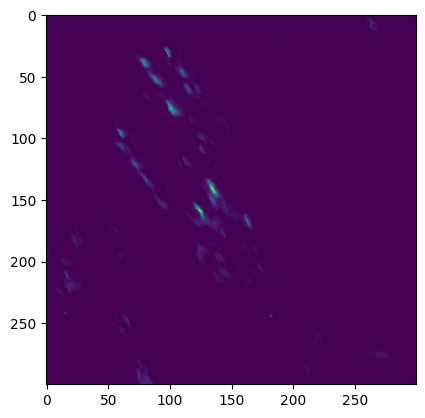

76


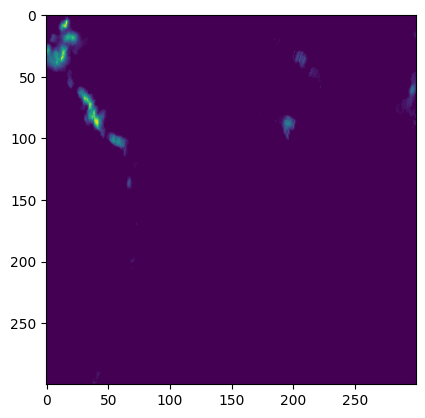

103


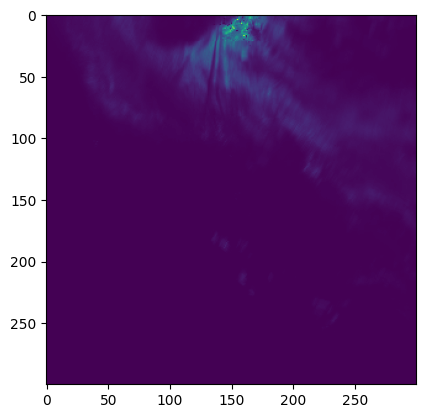

74


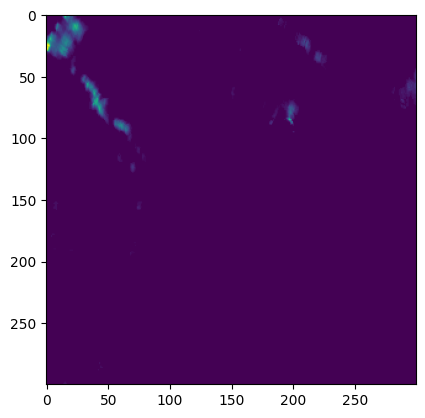

156


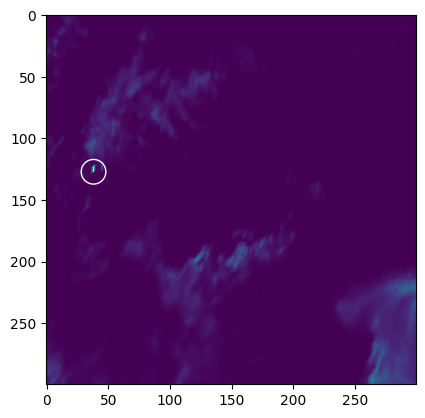

33


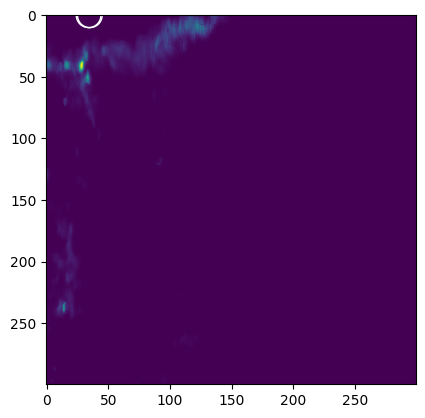

98


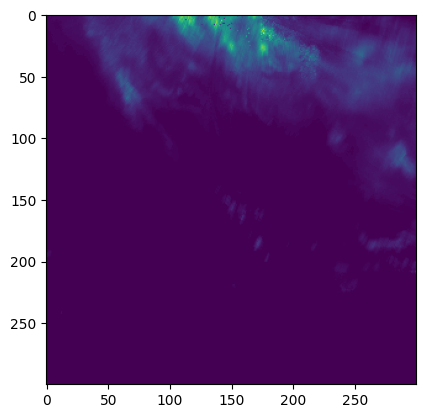

142


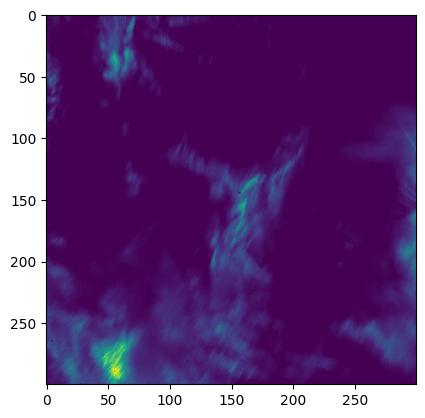

234


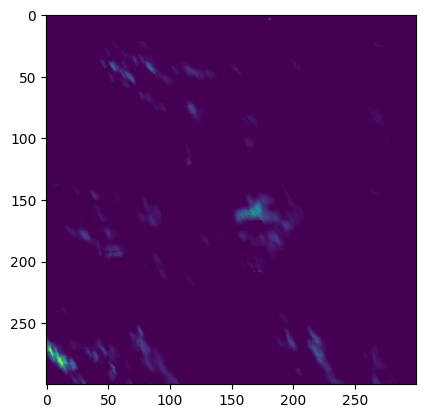

195


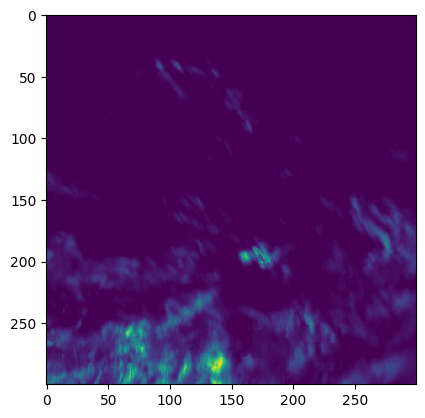

22


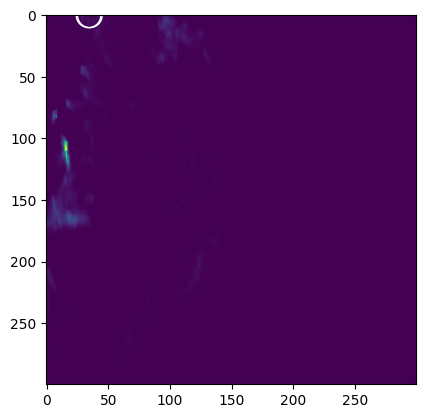

212


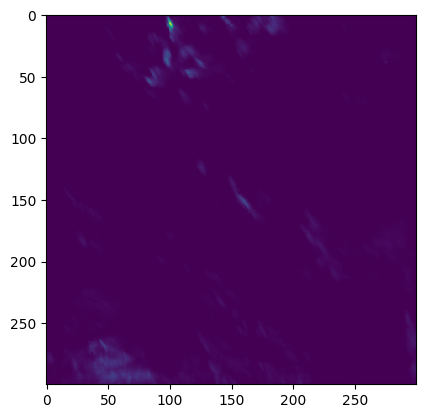

267


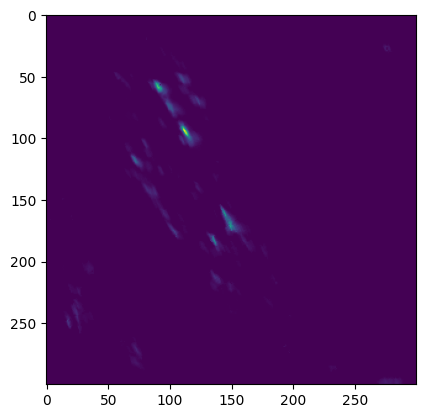

57


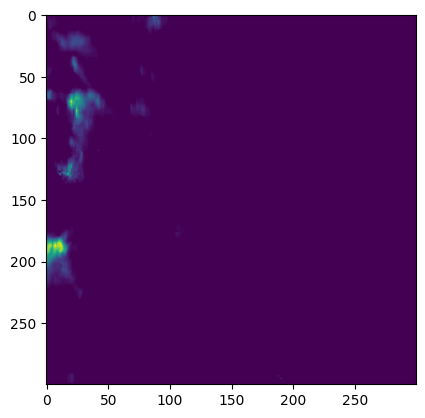

248


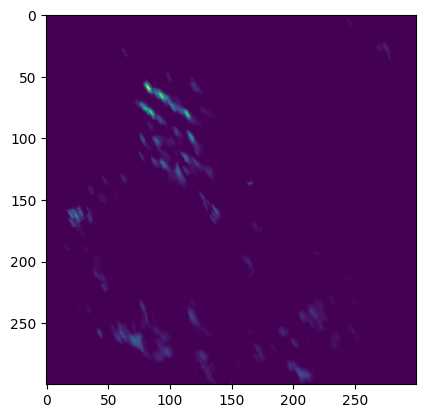

190


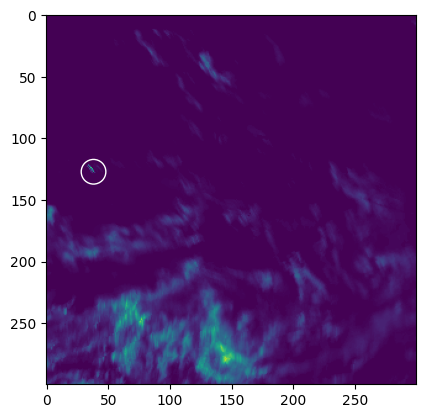

45


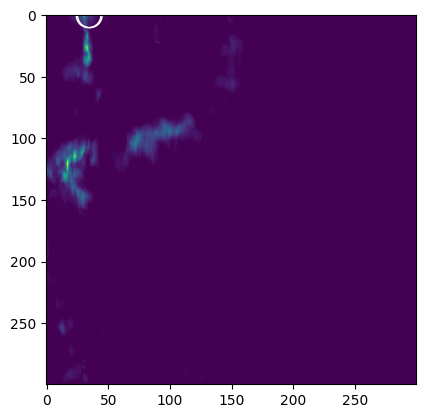

173


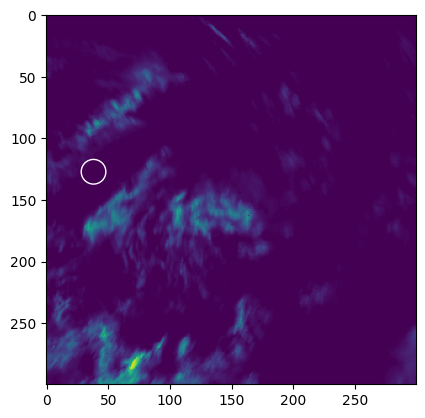

287


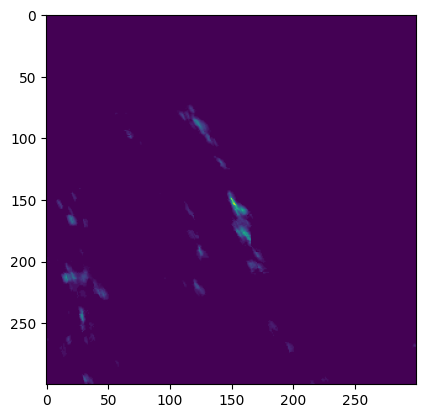

124


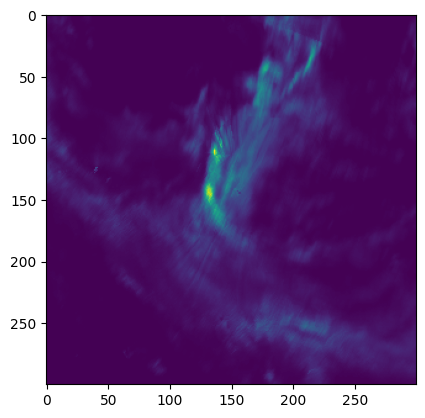

257


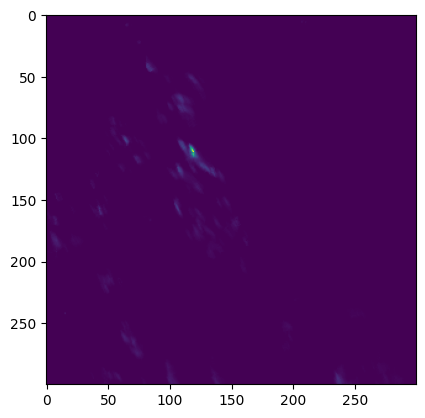

228


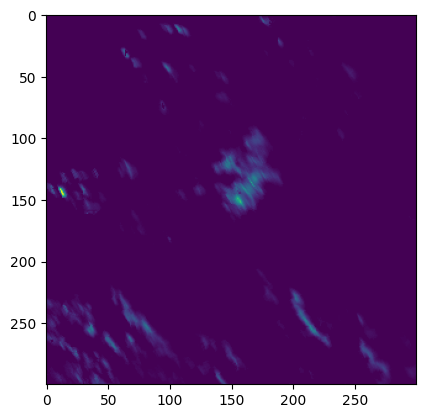

133


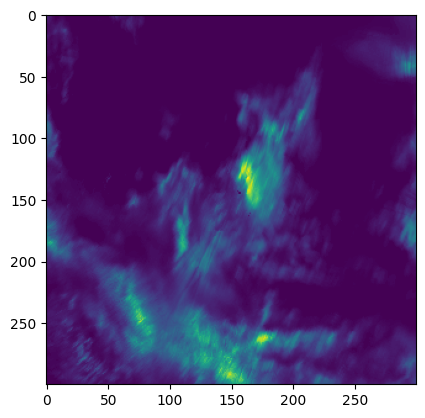

149


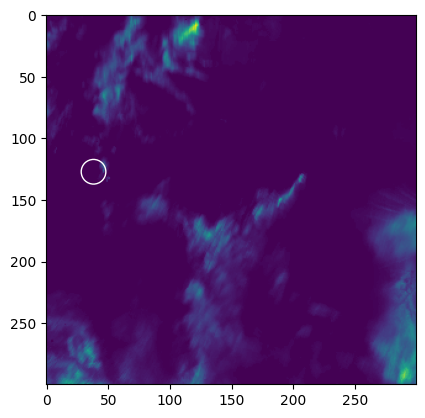

264


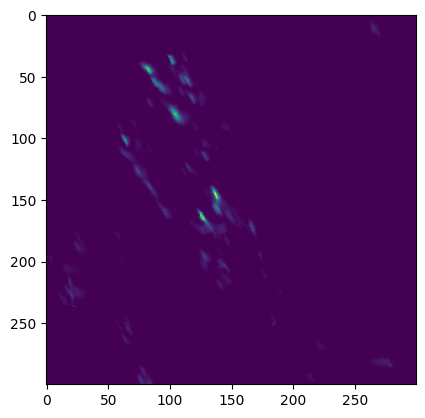

74


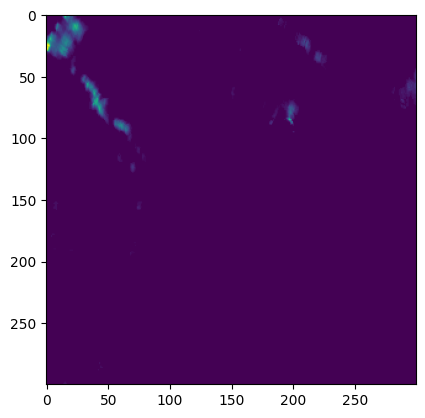

120


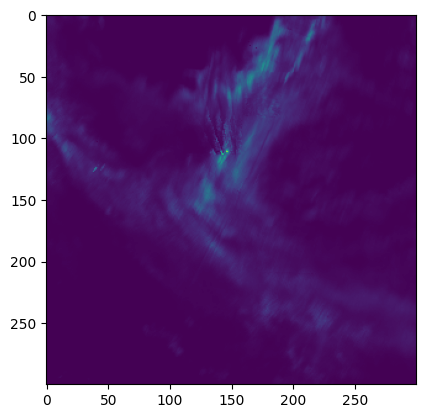

7


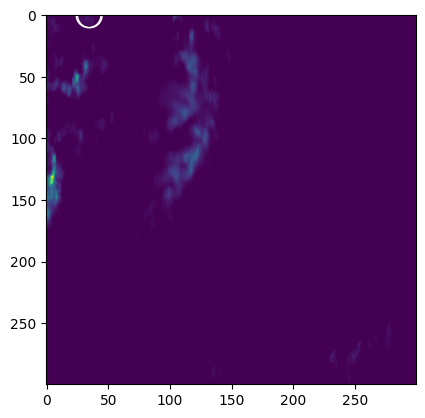

88


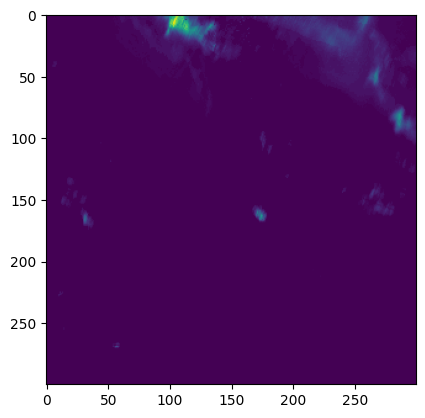

70


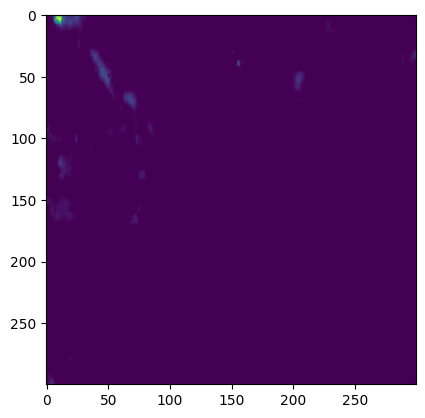

8


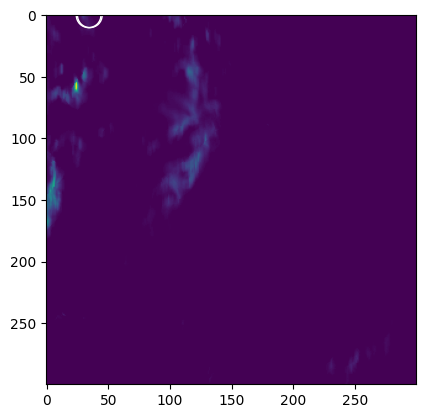

188


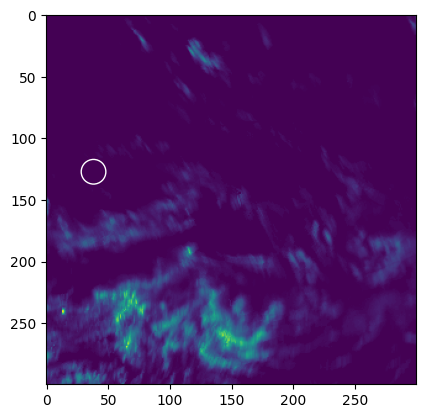

268


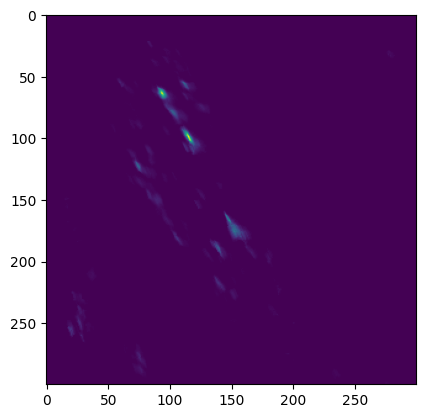

253


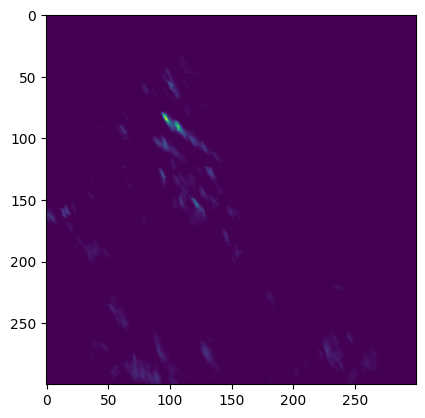

197


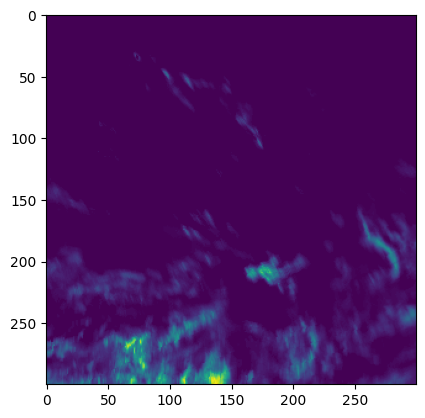

210


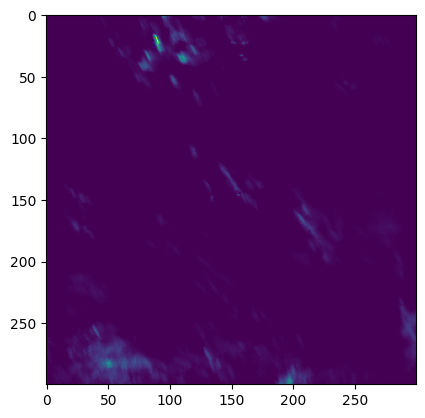

151


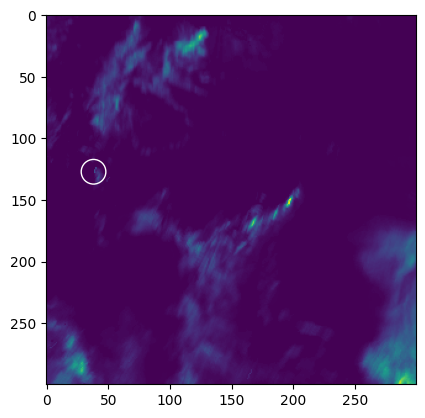

276


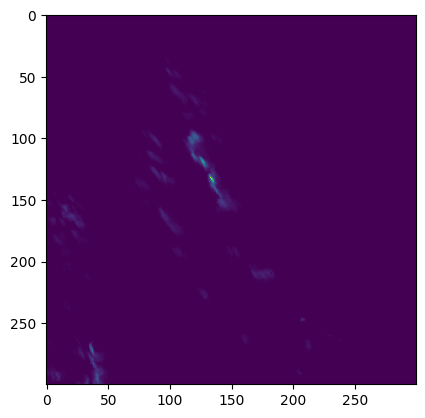

239


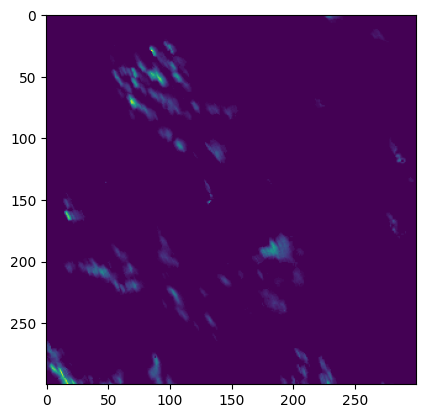

4


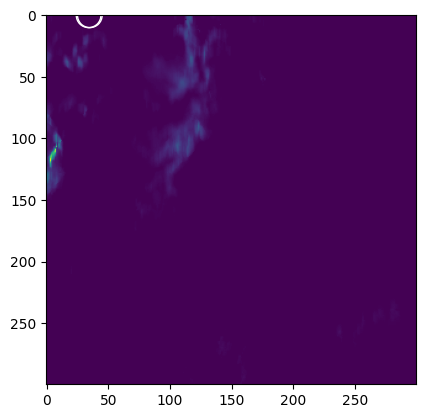

227


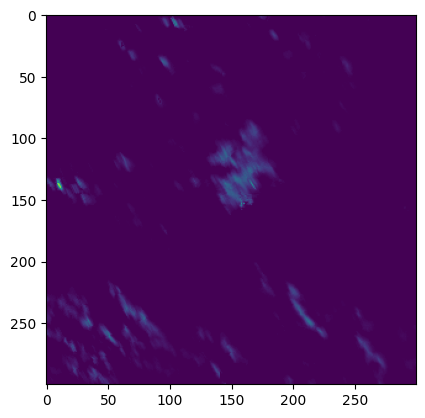

163


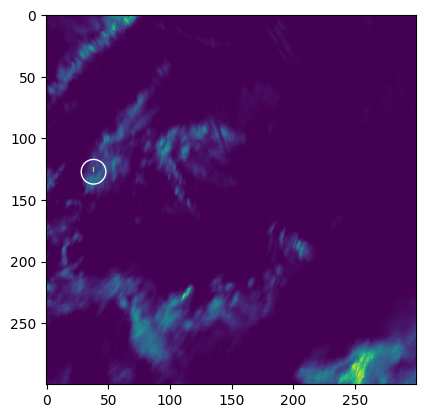

199


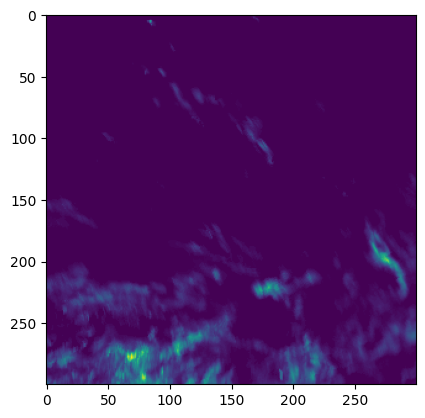

121


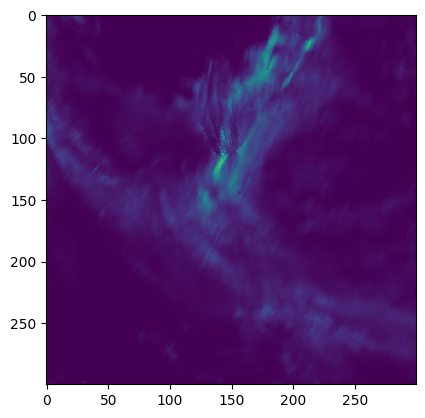

262


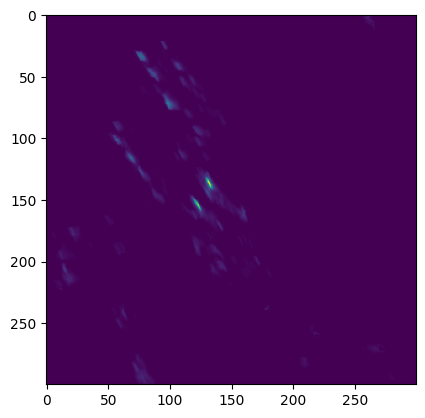

149


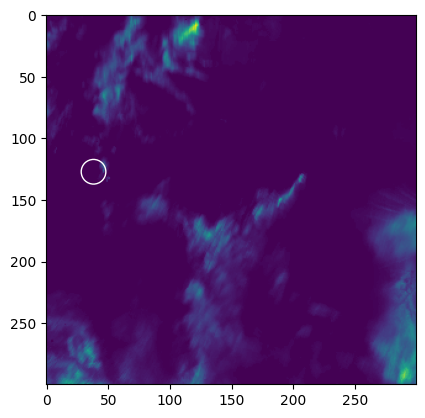

11


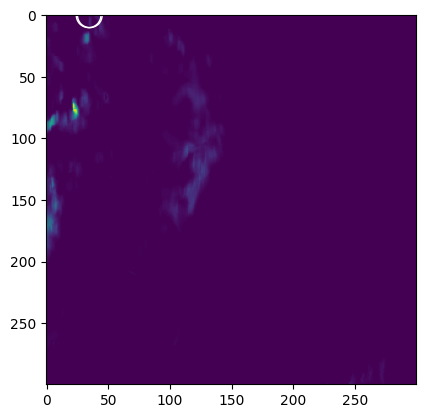

66


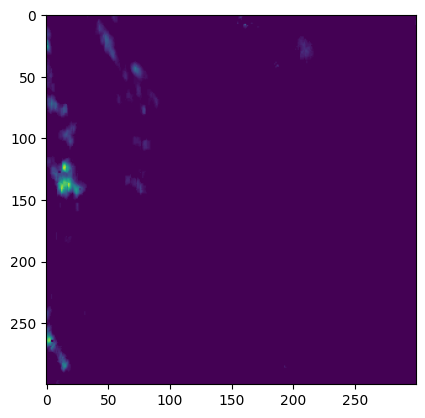

116


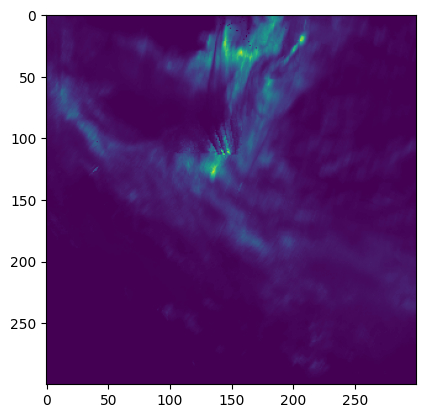

276


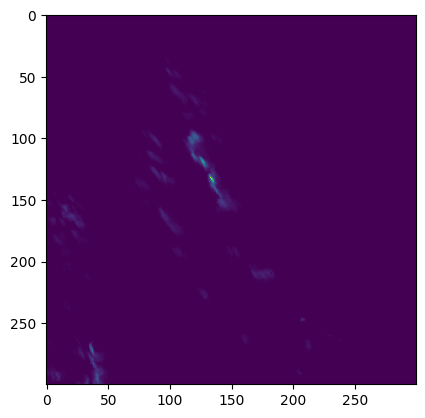

100


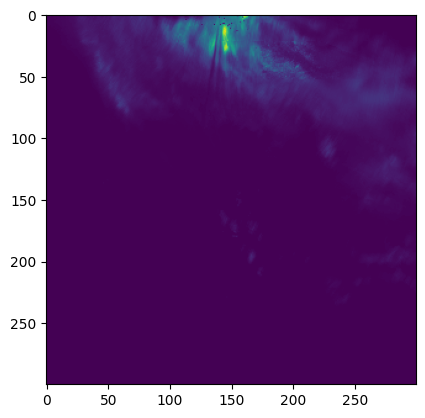

236


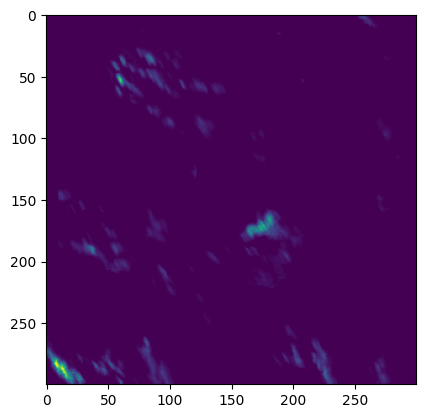

248


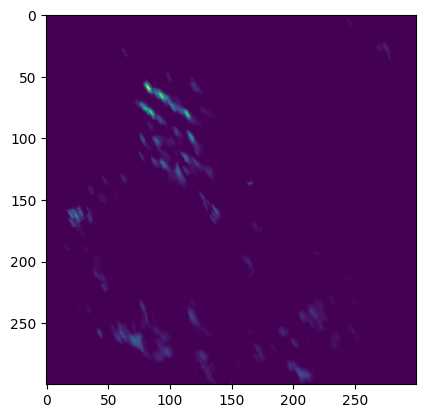

In [72]:
def csv_to_list(csv_file_path):
    data_list = []
    with open(csv_file_path, mode='r') as file:
        csv_reader = csv.reader(file)
        
        for row in csv_reader:
            row_list = [[int(num) for num in string.strip('[]').split()] for string in row]
            data_list.append(row_list)
    return data_list


rd_list = [rd.randint(0,np.shape(day_one)[0]-1) for i in range(100)]
print(rd_list)


outlier_list = csv_to_list('outlier_final_test.csv')
for rd_int in rd_list:
    print(rd_int)
    fig, ax = plt.subplots()
    im = ax.imshow(data_raw[rd_int,:,:])
    for element in outlier_list[rd_int]:
                    x=element[1]
                    y=element[0]
                    circle = plt.Circle((x,y), radius=10, edgecolor='white', facecolor='none')
                    ax.add_patch(circle)

    plt.show()


In [7]:
def export_list_to_csv(data, file_name):
    csv_file_path = file_name + ".csv"
    with open(csv_file_path, 'w', newline='') as csvfile:
        # Create a CSV writer object
        csv_writer = csv.writer(csvfile)
        
        # Write each sublist as a row in the CSV file
        for sublist in data:
            csv_writer.writerow(sublist)





In [33]:
def is_an_outlier_0(array):
    len = np.shape(array)[0]
    L = [[] for t in range(len)]
    for t in range(len):
        arrayt=array[t,:,:]
        frontier = np.mean(arrayt)+15*np.std(arrayt)
        A = np.argwhere(arrayt>frontier)
        L[t] = A
    return L

def is_an_outlier_0_2D(array):
    arrayt_non_zero = array[array>0]
    frontier = np.mean(arrayt_non_zero)+10*np.std(arrayt_non_zero)
    A = np.argwhere(array>frontier)
    return A

def is_an_outlier_1(array):
    len = np.shape(array)[0]
    L = [[] for t in range(len)]
    for t in range(len):
        print(t)
        arrayt=array[t,:,:]
        Score = score(arrayt,5)
        frontier = np.mean(Score)+10*np.std(Score)
        A = np.argwhere(abs(Score)>frontier)
        L[t]=A
    return L


def is_an_outlier_second_test(array):
    length = np.shape(array)[0]
    L=[]
    Kernel = np.array([[-1,-1,-1,-1,-1],[-1,-1,-1,-1,-1],[-1,-1,24,-1,-1],[-1,-1,-1,-1,-1],[-1,-1,-1,-1,-1]])
    for t in range(length):
        print(t)
        arrayt = array[t, :, :]
        S = convolve2d(arrayt,Kernel,mode='same')
        frontier = np.mean(S)+50*np.std(S)
        A = np.argwhere(abs(S)>frontier)
        L.append(A)
    return L


def is_an_outlier_1_2D(array):
    Score = score(array,1.5)
    frontier = np.mean(Score)+10*np.std(Score)
    A = list(np.argwhere(abs(Score)>frontier))
    return A


def is_an_outlier_2(array):
    len = np.shape(array)[0]
    L = [[] for t in range(len)]
    for t in range(len):
        print(t)
        arrayt=array[t,:,:]
        arrayt_non_zero = arrayt[arrayt>0]
        if arrayt_non_zero.size > 0:
            Q25 = np.percentile(arrayt_non_zero,25)
            Q75 = np.percentile(arrayt_non_zero,75)
            IQR = Q75-Q25
            frontier_2 = Q75 + 15*IQR
            A = list(np.argwhere(arrayt>frontier_2))
            L[t] = A
    return L

def is_an_outlier_3(array):
    L1 = is_an_outlier_0(array)
    L2 = is_an_outlier_second_test(array)
    L = []
    for i in range(len(L1)):
        A=[]
        for element in L1[i]:
            if element in L2[i]:
                A.append(element)
        L.append(A)
    return L


def is_an_outlier_4(array):
    L=[]
    kernel_3D = np.array([[[-1,-1,-1,],[-1,-1,-1],[-1,-1,-1]],[[-1,-1,-1],[-1,26,-1],[-1,-1,-1]],[[-1,-1,-1],[-1,-1,-1,],[-1,-1,-1]]])
    S = convolve(array,kernel_3D,mode='same')
    for t in range(length):
        print(t)
        St=S[t,:,:]
        frontier = np.mean(St)+100*np.std(St)
        A = np.argwhere(abs(St)>frontier)
        L.append(A)
    return L

def is_an_outlier_5(array):
    length = np.shape(array)[0]//6
    array_30_min = np.array([np.sum(array[6*i:6*i+6,:,:],axis=0) for i in range(length)])
    L=[]
    Kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
    for t in range(length):
        print(t)
        arrayt = array[t, :, :]
        S = convolve2d(arrayt,Kernel,mode='same')
        frontier = np.mean(S)+100*np.std(S)
        A = np.argwhere(abs(S)>frontier)
        for i in range(6):
            L.append(A)
    return L


In [22]:
def frontier_matrix(A, n):
    # Get the shape of the input matrix A
    N = np.shape(A)
    
    # Ensure that A can be divided into n x n sub-blocks
    assert N[0] % n == 0 and N[1] % n == 0, "Matrix dimensions should be divisible by n"
    
    # Reshape the matrix A to create sub-blocks
    A_cut = np.reshape(A, (N[0]//n,N[1]//n, n**2))
    
    # Compute the mean and standard deviation of each sub-block
    A_mean_reduced = np.mean(A_cut, axis=2)
    A_std_reduced = np.std(A_cut, axis=2)
    A_std_reduced[np.argwhere(A_std_reduced<2)]=2
    
    # Define the kernel
    K = np.ones((n,n))
    
    # Compute the tensordot product
    A_mean = np.kron(A_mean_reduced, K)
    A_std = np.kron(A_std_reduced, K)
    
    return [A_mean, A_std]

exemple = frontier_matrix(data_raw[0,:,:],50)
print(exemple[0])



[[20.7172 20.7172 20.7172 ... 31.676  31.676  31.676 ]
 [20.7172 20.7172 20.7172 ... 31.676  31.676  31.676 ]
 [20.7172 20.7172 20.7172 ... 31.676  31.676  31.676 ]
 ...
 [ 0.5664  0.5664  0.5664 ...  2.7792  2.7792  2.7792]
 [ 0.5664  0.5664  0.5664 ...  2.7792  2.7792  2.7792]
 [ 0.5664  0.5664  0.5664 ...  2.7792  2.7792  2.7792]]


In [34]:
def outlier_zone(array):
    len = np.shape(array)[0]
    L = [[] for t in range(len)]
    for t in range(len):
        arrayt=array[t,:,:]
        F = frontier_matrix(arrayt,50)
        frontier = F[0]+500*F[1]
        A = np.argwhere(arrayt-frontier>0)
        L[t] = A
    return L

def outlier_conv_zone(array):
    len = np.shape(array)[0]
    L = [[] for t in range(len)]
    for t in range(len):
        arrayt=array[t,:,:]
        Kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
        S = convolve2d(arrayt,Kernel,mode='same')
        F = frontier_matrix(S,50)
        frontier = F[0]+500*F[1]
        A = np.argwhere(S-frontier>0)
        L[t] = A
    return L


def outlier_zone_2_test(array):
    L1 = outlier_zone(array)
    L2 = is_an_outlier_second_test(array)
    L = []
    for i in range(len(L1)):
        A=[]
        for element in L1[i]:
            if element in L2[i]:
                A.append(element)
        L.append(A)
    return L

def outlier_zone_2_test_bis(array):
    L1 = outlier_zone(array)
    L2 = outlier_conv_zone(array)
    L = []
    for i in range(len(L1)):
        A=[]
        for element in L1[i]:
            if element in L2[i]:
                A.append(element)
        L.append(A)
    return L

In [37]:
List_outliers = outlier_zone_2_test_bis(data_raw)

export_list_to_csv(List_outliers,'outlier_zone_test')


In [ ]:
rd_list = [rd.randint(0,500) for i in range(100)]
print(rd_list)

outlier_list = List_outliers
for rd_int in rd_list:
    print(rd_int)
    fig, ax = plt.subplots()
    im = ax.imshow(data_raw[rd_int,:,:])
    for element in outlier_list[rd_int]:
                    print(element)
                    x=element[1]
                    y=element[0]
                    circle = plt.Circle((x,y), radius=10, edgecolor='white', facecolor='none')
                    ax.add_patch(circle)

    plt.show()


In [ ]:
rd_list = [rd.randint(0,np.shape(data_raw)[0]) for i in range(100)]
print(rd_list)


for rd_int in rd_list:
    print(rd_int)
    array_t=data_raw[rd_int,:,:]
    outlier_list= is_an_outlier_1_2D(array_t)
    fig, ax = plt.subplots()
    im = ax.imshow(array_t)
    for element in outlier_list:
                    print(element)
                    x=element[1]
                    y=element[0]
                    circle = plt.Circle((x,y), radius=10, edgecolor='white', facecolor='none')
                    ax.add_patch(circle)

    plt.show()

In [ ]:
zip_file_path = "data/2018.zip"

with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        all_files = zip_ref.namelist()
        for file in all_files:
            if file.endswith(".npy"):
                with zip_ref.open(file) as file_in_zip:
                    npy_bytes = file_in_zip.read()
                    npy_file_like = io.BytesIO(npy_bytes)
                    npy_array = np.load(npy_file_like)
                    print(npy_array)
                    npy_file_like.close()


In [70]:
def outlier_final(array):
    length = array.shape[0]
    L = []
    kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    
    # Sum the array every 48 elements along the first axis
    data_4_hours = np.array([np.sum(array[48 * i:48 * (i + 1)], axis=0) for i in range(length // 48)])
    
    # Apply convolution with the kernel to each 4-hour segment
    S = np.array([convolve2d(element, kernel, mode='same') for element in data_4_hours])
    
    for t in range(len(S)):
        St = S[t]
        Dt = data_4_hours[t]
        frontier_Dt = np.mean(Dt) + 5 * np.std(Dt)
        frontier_St = np.mean(St) + 30 * np.std(St)
        
        A = np.argwhere((np.abs(St) > frontier_St) & (np.abs(Dt) > frontier_Dt))
        
        for _ in range(48):  # Assuming you want to append A 48 times
            L.append(A)
            
    return L


In [71]:
List_outliers = outlier_final(day_one)

export_list_to_csv(List_outliers,'outlier_final_test')


In [ ]:
zip_file_path = "data/2018.zip"

with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        all_files = zip_ref.namelist()
        for file in all_files:
            if file.endswith(".npy"):
                with zip_ref.open(file) as file_in_zip:
                    npy_bytes = file_in_zip.read()
                    npy_file_like = io.BytesIO(npy_bytes)
                    npy_array = np.load(npy_file_like)
                    outliers_list = 
                    npy_file_like.close()
